# Model Comparison for Pairs Trading Forecasting

This notebook consolidates model evaluation outputs across the project and compares forecasting models on two layers: **forecast quality** (MSE, R², IC, directional accuracy) and **validation trading quality** (Sharpe, Fitness, returns). Forecast metrics are used as a screening layer, while the final live-model choice should come from causal validation trading performance.

## 1. Imports and Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
import subprocess
import shutil
import matplotlib.pyplot as plt
plt.style.use('default')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'run_pipeline.ps1').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root containing run_pipeline.ps1 and src/')

ROOT = find_repo_root(Path.cwd().resolve())
DATA_PROCESSED = ROOT / 'data' / 'processed'
OUTPUT_SUMMARY = DATA_PROCESSED / 'model_comparison_summary.csv'

KEYWORDS = (
    'eval', 'evaluation', 'holdout', 'validation', 'results', 'metrics', 'summary',
    'forecast', 'tuning', 'prediction', 'predictions', 'signal', 'signals'
)
EXCLUDE_DIR_NAMES = {'.venv', '.git', '__pycache__', '.ipynb_checkpoints'}

KNOWN_MODELS = ['ou', 'arma', 'linear', 'xgboost', 'lstm', 'lstm_encoder_decoder']
KNOWN_SPREADS = ['ols', 'kalman']

print(f'Repo root resolved to: {ROOT}')
print(f'Processed data directory: {DATA_PROCESSED}')

Repo root resolved to: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading
Processed data directory: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed


## 2. Cache-Aware Pipeline Run (No Tuning)

In [2]:
# User-editable settings
TARGET_MODELS = ['arma', 'linear', 'xgboost', 'lstm', 'lstm_encdec', 'ou']
HORIZON = 10
TOP_K = 20
RUN_PIPELINE_IF_MISSING = True
FORCE_RERUN = False
SKIP_BACKTESTING = True
VERBOSE_PIPELINE = True

print('Section 2 configuration loaded:')
print(f'- TARGET_MODELS={TARGET_MODELS}')
print(f'- HORIZON={HORIZON}, TOP_K={TOP_K}')
print(f'- RUN_PIPELINE_IF_MISSING={RUN_PIPELINE_IF_MISSING}')
print(f'- FORCE_RERUN={FORCE_RERUN}')
print(f'- SKIP_BACKTESTING={SKIP_BACKTESTING}')
print(f'- VERBOSE_PIPELINE={VERBOSE_PIPELINE}')

Section 2 configuration loaded:
- TARGET_MODELS=['arma', 'linear', 'xgboost', 'lstm', 'lstm_encdec', 'ou']
- HORIZON=10, TOP_K=20
- RUN_PIPELINE_IF_MISSING=True
- FORCE_RERUN=False
- SKIP_BACKTESTING=True
- VERBOSE_PIPELINE=True


In [3]:
pipeline_script = ROOT / 'run_pipeline.ps1'
raw_data_dir = ROOT / 'data' / 'raw'
pair_datasets_dir = DATA_PROCESSED / 'pair_datasets'
selected_pairs_dir = DATA_PROCESSED / 'selected_pairs'

if not pipeline_script.exists():
    raise FileNotFoundError(f'Missing pipeline script: {pipeline_script}')

def list_files(patterns):
    out = []
    for pat in patterns:
        out.extend(sorted(ROOT.glob(pat)))
    # keep only files and de-duplicate
    uniq = []
    seen = set()
    for p in out:
        if p.is_file() and p not in seen:
            seen.add(p)
            uniq.append(p)
    return uniq

def find_model_artifacts(model):
    # model values are pipeline args: ou/arma/linear/xgboost/lstm/lstm_encdec
    pats = []
    if model == 'arma':
        pats = [
            'data/processed/predictions/arma_ols/*/summary_metrics*.csv',
            'data/processed/predictions/arma_kalman/*/summary_metrics*.csv',
            'data/processed/predictions/arma_ols/*/all_forecasts*.csv',
            'data/processed/predictions/arma_kalman/*/all_forecasts*.csv',
            'data/processed/predictions/arma_ols/*/predictions*.csv',
            'data/processed/predictions/arma_kalman/*/predictions*.csv',
            'data/processed/arma_tuning_outputs/arma_ols/*.csv',
            'data/processed/arma_tuning_outputs/arma_kalman/*.csv',
            'data/processed/arma_holdout_outputs/arma_ols/**/*.csv',
            'data/processed/arma_holdout_outputs/arma_kalman/**/*.csv',
        ]
    elif model == 'linear':
        pats = [
            'data/processed/linear_regression_outputs/linear_regression_ols/all_val_results.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/all_test_results.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/fold_summary.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/*/summary_metrics*.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/*/all_forecasts*.csv',
            'data/processed/linear_regression_outputs/linear_regression_ols/**/lr_metrics_*.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/all_val_results.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/all_test_results.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/fold_summary.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/*/summary_metrics*.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/*/all_forecasts*.csv',
            'data/processed/linear_regression_outputs/linear_regression_kalman/**/lr_metrics_*.csv',
            'data/processed/predictions/linear_regression_ols/*/predictions.csv',
            'data/processed/predictions/linear_regression_kalman/*/predictions.csv',
        ]
    elif model == 'xgboost':
        pats = [
            'data/processed/predictions/xgboost_ols/*/metrics.csv',
            'data/processed/predictions/xgboost_kalman/*/metrics.csv',
            'data/processed/predictions/xgboost_ols/*/predictions.csv',
            'data/processed/predictions/xgboost_kalman/*/predictions.csv',
            'data/processed/predictions/xgboost_ols/best_params.csv',
            'data/processed/predictions/xgboost_kalman/best_params.csv',
            'data/processed/predictions/xgboost_ols/tuning_summary.csv',
            'data/processed/predictions/xgboost_kalman/tuning_summary.csv',
        ]
    elif model == 'lstm':
        pats = [
            'data/processed/predictions/lstm_ols/metrics_summary.csv',
            'data/processed/predictions/lstm_kalman/metrics_summary.csv',
            'data/processed/predictions/lstm_ols/tuning_results.csv',
            'data/processed/predictions/lstm_kalman/tuning_results.csv',
            'data/processed/predictions/lstm_ols/*/predictions.csv',
            'data/processed/predictions/lstm_kalman/*/predictions.csv',
        ]
    elif model == 'lstm_encdec':
        pats = [
            'data/processed/predictions/lstm_encoder_decoder_ols/metrics_summary.csv',
            'data/processed/predictions/lstm_encoder_decoder_kalman/metrics_summary.csv',
            'data/processed/predictions/lstm_encoder_decoder_ols/tuning_results.csv',
            'data/processed/predictions/lstm_encoder_decoder_kalman/tuning_results.csv',
            'data/processed/predictions/lstm_encoder_decoder_ols/*/predictions.csv',
            'data/processed/predictions/lstm_encoder_decoder_kalman/*/predictions.csv',
        ]
    elif model == 'ou':
        pats = [
            'data/processed/ou_signals_static.csv',
            'data/processed/ou_signals_kalman.csv',
            'data/processed/ou_signals*.csv',
            'data/processed/**/ou_signals*.csv',
            'data/processed/**/ou_*signals*.csv',
        ]
    return list_files(pats)

def summarize_cache(target_models):
    rows = []
    for m in target_models:
        arts = find_model_artifacts(m)
        status = 'forced_rerun' if FORCE_RERUN else ('present' if len(arts) else 'missing')
        rows.append({
            'model': m,
            'found_artifacts_count': len(arts),
            'status': status,
            'sample_artifact_paths': '\n'.join(str(p.relative_to(ROOT)) for p in arts[:5])
        })
    return pd.DataFrame(rows)

def is_nonempty_dir(path: Path) -> bool:
    return path.exists() and any(path.rglob('*'))

def build_skip_flags():
    flags = []
    has_raw_data = is_nonempty_dir(raw_data_dir)
    has_pair_datasets = is_nonempty_dir(pair_datasets_dir)
    has_selected_pairs = is_nonempty_dir(selected_pairs_dir)

    if has_raw_data:
        flags.append('-SkipDownload')

    if has_pair_datasets:
        flags.extend(['-SkipPrep', '-SkipPairDiscovery', '-SkipPairSelection', '-SkipDatasetBuilding'])
    elif has_selected_pairs:
        flags.extend(['-SkipPrep', '-SkipPairDiscovery', '-SkipPairSelection'])

    flags.append('-SkipModelTraining')

    if SKIP_BACKTESTING:
        flags.append('-SkipBacktesting')

    return flags, has_raw_data

def run_logged(cmd, label):
    print('\n' + '=' * 100)
    print(f'RUNNING: {label}')
    print('COMMAND:', ' '.join(str(x) for x in cmd))

    if VERBOSE_PIPELINE:
        proc = subprocess.Popen(
            [str(x) for x in cmd],
            cwd=ROOT,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end='')
        ret = proc.wait()
    else:
        ret = subprocess.run([str(x) for x in cmd], cwd=ROOT).returncode

    print(f'EXIT CODE: {ret}')
    if ret != 0:
        raise RuntimeError(f'Command failed during: {label}')

def run_model_python_fallback(model, skip_flags, has_raw_data):
    py = shutil.which('python') or shutil.which('python3')
    if py is None:
        raise EnvironmentError('Python executable not found for fallback execution.')

    if not has_raw_data:
        raise RuntimeError('Raw data missing and PowerShell unavailable; cannot perform Step 0 download in fallback mode.')

    skip = set(skip_flags)

    if '-SkipPrep' not in skip:
        run_logged([py, 'prepare_data.py'], f'{model}: Step 1 Data Preparation')

    if '-SkipPairDiscovery' not in skip:
        run_logged([py, '-m', 'src.clustering.pca'], f'{model}: Step 2a PCA')
        run_logged([py, '-m', 'src.clustering.optics'], f'{model}: Step 2b OPTICS')
        run_logged([py, '-m', 'src.pairs_discovery.rank_pairs'], f'{model}: Step 2c Rank Pairs')

    if '-SkipPairSelection' not in skip:
        run_logged([py, '-m', 'src.pairs_discovery.pairs_selection', '--top_k', str(TOP_K)], f'{model}: Step 3 Pair Selection')

    if '-SkipDatasetBuilding' not in skip:
        run_logged([py, '-m', 'src.models.pair_dataset_builder'], f'{model}: Step 4 Dataset Building')

    # Step 5 intentionally skipped by design

    if model == 'ou':
        run_logged([py, '-m', 'src.models.ou'], f'{model}: Step 6 Frozen OU')
    elif model == 'arma':
        run_logged([py, '-m', 'src.models.arma', '--spread_col', 'spread_ols', '--p', '9', '--q', '8', '--horizon', str(HORIZON), '--eval_split', 'val'], f'{model}: Step 6 Frozen ARMA OLS')
        run_logged([py, '-m', 'src.models.arma', '--spread_col', 'spread_kalman', '--p', '6', '--q', '2', '--horizon', str(HORIZON), '--eval_split', 'val'], f'{model}: Step 6 Frozen ARMA Kalman')
    elif model == 'linear':
        run_logged([py, '-m', 'src.models.linear_regression'], f'{model}: Step 6 Frozen Linear')
    elif model == 'xgboost':
        run_logged([py, '-m', 'src.models.xgboost_model', '--spread_type', 'both', '--no_tune'], f'{model}: Step 6 Frozen XGBoost')
    elif model == 'lstm':
        run_logged([py, '-m', 'src.models.lstm', '--spread', 'ols', 'kalman', '--hidden', '64', '--window_size', '20', '--lr', '0.001', '--no_tune'], f'{model}: Step 6 Frozen LSTM')
    elif model == 'lstm_encdec':
        run_logged([py, '-m', 'src.models.lstm_encoder_decoder', '--spread', 'ols', 'kalman', '--hidden', '64', '--window_size', '20', '--lr', '0.001', '--no_tune'], f'{model}: Step 6 Frozen LSTM-EncDec')
    else:
        raise ValueError(f'Unsupported model in fallback: {model}')

    if '-SkipBacktesting' not in skip:
        run_logged([py, '-m', 'src.backtest.backtest_engine'], f'{model}: Step 7 Backtesting')
        run_logged([py, '-m', 'src.backtest.backtest_engine', '--holdout'], f'{model}: Step 7 Holdout Backtesting')

cache_before = summarize_cache(TARGET_MODELS)
print('Cache status before run:')
display(cache_before)

if FORCE_RERUN:
    models_to_run = list(TARGET_MODELS)
else:
    models_to_run = cache_before.loc[cache_before['status'] == 'missing', 'model'].tolist()

if not RUN_PIPELINE_IF_MISSING:
    models_to_run = []

print(f'Models selected for execution: {models_to_run}')

skip_flags, has_raw_data = build_skip_flags()
print(f'Dynamic skip flags: {skip_flags}')

ps_exe = shutil.which('pwsh') or shutil.which('powershell')

ran_models = []
if models_to_run:
    for model in models_to_run:
        if ps_exe is not None:
            cmd = [
                ps_exe, '-NoProfile', '-ExecutionPolicy', 'Bypass',
                '-File', str(pipeline_script),
                '-model', model,
                '-horizon', str(HORIZON),
                '-top_k', str(TOP_K),
            ] + skip_flags
            run_logged(cmd, f'run_pipeline.ps1 for missing model={model}')
        else:
            print('PowerShell not found. Using Python fallback for this model.')
            run_model_python_fallback(model, skip_flags, has_raw_data)

        ran_models.append(model)
else:
    print('No missing models detected (or auto-run disabled).')

cache_after = summarize_cache(TARGET_MODELS)
display(cache_after)

cached_models = cache_before.loc[(cache_before['status'] == 'present') & (~cache_before['model'].isin(ran_models)), 'model'].tolist()
still_missing = cache_after.loc[cache_after['found_artifacts_count'] == 0, 'model'].tolist()

print('\nSection 2 summary:')
print(f'- Models already cached: {cached_models}')
print(f'- Models run in this session: {ran_models}')
print(f'- Models still missing artifacts: {still_missing}')
print(f'- Backtesting skipped: {SKIP_BACKTESTING}')

Cache status before run:


,model,found_artifacts_count,status,sample_artifact_paths
0,arma,173,present,data/processed/predictions/arma_ols/2010_2012/...
1,linear,256,present,data/processed/linear_regression_outputs/linea...
2,xgboost,24,present,data/processed/predictions/xgboost_ols/2010_20...
3,lstm,14,present,data/processed/predictions/lstm_ols/metrics_su...
4,lstm_encdec,14,present,data/processed/predictions/lstm_encoder_decode...
5,ou,2,present,data/processed/ou_signals_static.csv\ndata/pro...


Models selected for execution: []
Dynamic skip flags: ['-SkipDownload', '-SkipPrep', '-SkipPairDiscovery', '-SkipPairSelection', '-SkipDatasetBuilding', '-SkipModelTraining', '-SkipBacktesting']
No missing models detected (or auto-run disabled).


,model,found_artifacts_count,status,sample_artifact_paths
0,arma,173,present,data/processed/predictions/arma_ols/2010_2012/...
1,linear,256,present,data/processed/linear_regression_outputs/linea...
2,xgboost,24,present,data/processed/predictions/xgboost_ols/2010_20...
3,lstm,14,present,data/processed/predictions/lstm_ols/metrics_su...
4,lstm_encdec,14,present,data/processed/predictions/lstm_encoder_decode...
5,ou,2,present,data/processed/ou_signals_static.csv\ndata/pro...



Section 2 summary:
- Models already cached: ['arma', 'linear', 'xgboost', 'lstm', 'lstm_encdec', 'ou']
- Models run in this session: []
- Models still missing artifacts: []
- Backtesting skipped: True


## 3. Locate and Load Result Files

In [4]:
def should_exclude(path: Path) -> bool:
    return any(part in EXCLUDE_DIR_NAMES for part in path.parts)

def is_likely_result_file(path: Path) -> bool:
    if path.suffix.lower() not in {'.csv', '.json'}:
        return False
    text = path.as_posix().lower()
    return any(k in text for k in KEYWORDS)

def source_priority(path: Path) -> int:
    s = path.as_posix().lower()
    metric_keywords = ('metrics', 'summary', 'results', 'forecast', 'holdout', 'validation', 'eval')
    prediction_keywords = ('prediction', 'predictions')
    signal_keywords = ('signal', 'signals')
    if any(k in s for k in metric_keywords):
        return 0
    if any(k in s for k in prediction_keywords):
        return 1
    if any(k in s for k in signal_keywords):
        return 2
    return 3

candidate_files = []
for p in ROOT.rglob('*'):
    if not p.is_file():
        continue
    if should_exclude(p):
        continue
    if is_likely_result_file(p):
        candidate_files.append(p)

candidate_files = sorted(candidate_files, key=lambda p: (source_priority(p), str(p).lower()))

# Focus on likely model outputs first
priority_files = [p for p in candidate_files if 'data/processed' in p.as_posix().lower()]
other_files = [p for p in candidate_files if p not in priority_files]

print(f'Total candidate files found: {len(candidate_files)}')
print(f'  In data/processed: {len(priority_files)}')
print(f'  Outside data/processed: {len(other_files)}')

candidate_df = pd.DataFrame({
    'path': [str(p.relative_to(ROOT)) for p in candidate_files],
    'suffix': [p.suffix.lower() for p in candidate_files],
    'priority': [source_priority(p) for p in candidate_files],
}).sort_values(['priority', 'path']).reset_index(drop=True)

candidate_df.head(80)

Total candidate files found: 1058
  In data/processed: 1046
  Outside data/processed: 12


,path,suffix,priority
0,data/clustering/2010_2012/optics_summary.csv,.csv,0
1,data/clustering/2011_2013/optics_summary.csv,.csv,0
2,data/clustering/2012_2014/optics_summary.csv,.csv,0
3,data/clustering/2013_2015/optics_summary.csv,.csv,0
4,data/clustering/2014_2016/optics_summary.csv,.csv,0
...,...,...,...
75,data/processed/arma_holdout_outputs/arma_ols/2...,.csv,0
76,data/processed/arma_holdout_outputs/arma_ols/2...,.csv,0
77,data/processed/arma_holdout_outputs/arma_ols/2...,.csv,0
78,data/processed/arma_holdout_outputs/arma_ols/2...,.csv,0


## 4. Inspect Schemas and Infer Metadata

In [5]:
def infer_model_from_path(path: Path) -> str:
    s = path.as_posix().lower()
    if 'lstm_encoder_decoder' in s or 'encdec' in s:
        return 'lstm_encoder_decoder'
    if 'xgboost' in s:
        return 'xgboost'
    if 'lstm' in s:
        return 'lstm'
    if 'arma' in s:
        return 'arma'
    if re.search(r'(^|[_/\-])ou([_/\-]|$)', s):
        return 'ou'
    if 'linear' in s:
        return 'linear'
    return 'unknown'

def infer_spread_from_path(path: Path) -> str:
    s = path.as_posix().lower()
    if 'kalman' in s:
        return 'kalman'
    if 'ols' in s:
        return 'ols'
    return 'unknown'

def infer_horizon_from_path(path: Path):
    s = path.as_posix().lower()
    m = re.search(r'horizon[_=\-]?(\d+)', s)
    if m:
        return int(m.group(1))
    return np.nan

def infer_split_from_text(text: str) -> str:
    t = str(text).lower()
    if any(x in t for x in ['holdout', 'test', 'out_of_sample', 'oos']):
        return 'holdout'
    if any(x in t for x in ['val', 'validation']):
        return 'validation'
    return 'unknown'

schema_rows = []
for p in priority_files:
    rel = p.relative_to(ROOT)
    row = {
        'path': str(rel),
        'model_guess': infer_model_from_path(p),
        'spread_guess': infer_spread_from_path(p),
        'horizon_guess': infer_horizon_from_path(p),
        'readable': False,
        'n_rows': np.nan,
        'columns': None,
        'error': None,
    }
    try:
        if p.suffix.lower() == '.csv':
            df = pd.read_csv(p)
        elif p.suffix.lower() == '.json':
            with open(p, 'r') as f:
                obj = json.load(f)
            df = pd.json_normalize(obj) if isinstance(obj, (list, dict)) else pd.DataFrame()
        else:
            raise ValueError('Unsupported suffix')
        row['readable'] = True
        row['n_rows'] = len(df)
        row['columns'] = ', '.join(df.columns.astype(str).tolist())
    except Exception as e:
        row['error'] = str(e)
    schema_rows.append(row)

schema_df = pd.DataFrame(schema_rows).sort_values('path').reset_index(drop=True)
print(f'Readable files in data/processed candidates: {schema_df.readable.sum()} / {len(schema_df)}')
schema_df.head(60)

Readable files in data/processed candidates: 1046 / 1046


,path,model_guess,spread_guess,horizon_guess,readable,n_rows,columns,error
0,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
1,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None
2,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
3,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None
4,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
5,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None
6,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
7,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None
8,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,208,"forecast_origin_date, target_date, current_spr...",None
9,data/processed/arma_holdout_outputs/arma_kalma...,arma,kalman,NaN,True,1,"pair, window_label, eval_split, spread_col, se...",None


## 5. Standardize Results Into a Unified Format

In [6]:
STANDARDIZED_COLS = [
  'model',
  'spread_type',
  'dataset_split',
  'horizon',
  'window_label',
  'metric_source',
  'source_kind',
  'aggregation_level',
  'is_tuning',
  'mse',
  'rmse',
  'mae',
  'mse_comparable',
  'directional_weighted_mse',
  'directional_accuracy',
  'information_coefficient',
  'notes'
]

DEFAULT_HORIZON_MODELS = {'arma', 'linear', 'xgboost', 'lstm', 'lstm_encdec', 'ou'}

def to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def first_existing(row, keys):
    for k in keys:
        if k in row and pd.notna(row[k]):
            return row[k]
    return np.nan

def normalize_spread(raw):
    if pd.isna(raw):
        return 'unknown'
    s = str(raw).lower()
    if s == 'static':
        return 'ols'
    if 'kalman' in s:
        return 'kalman'
    if 'ols' in s:
        return 'ols'
    return s

def infer_window_from_path(path: Path):
    m = re.search(r'(20\d{2}_20\d{2})', path.as_posix())
    return m.group(1) if m else np.nan

def normalize_split(raw, fallback_path: Path):
    split = infer_split_from_text(raw)
    if split != 'unknown':
        return split
    return infer_split_from_text(fallback_path.as_posix())

def append_row(rows, **kwargs):
    row = {c: np.nan for c in STANDARDIZED_COLS}
    row.update(kwargs)
    rows.append(row)

def normalize_model_name(raw):
    s = str(raw).lower()
    if 'encoder_decoder' in s or s == 'lstm_encoder_decoder':
        return 'lstm_encdec'
    return s

def standardize_id_columns(df):
    out = df.copy()
    rename = {}
    for c in out.columns:
        lc = str(c).strip().lower()
        if lc == 'date':
            rename[c] = 'Date'
        elif lc == 'pair':
            rename[c] = 'pair'
        elif lc == 'training_window':
            rename[c] = 'training_window'
        elif lc == 'method':
            rename[c] = 'method'
    out = out.rename(columns=rename)
    if 'Date' in out.columns:
        out['Date'] = pd.to_datetime(out['Date'], errors='coerce')
    if 'pair' in out.columns:
        out['pair'] = out['pair'].astype(str)
    return out

def compute_ou_metrics_from_signal_file(signal_path: Path):
    rows = []
    rel_src = str(signal_path.relative_to(ROOT))
    try:
        signal_df = pd.read_csv(signal_path)
    except Exception as e:
        skipped_files.append({'path': rel_src, 'reason': f'OU fallback failed: read_failed ({e})'})
        return rows

    if signal_df.empty:
        skipped_files.append({'path': rel_src, 'reason': 'OU fallback failed: empty signal file'})
        return rows

    signal_df = standardize_id_columns(signal_df)
    if not {'Date', 'pair', 'pred_spread_10d'}.issubset(signal_df.columns):
        skipped_files.append({'path': rel_src, 'reason': 'OU fallback failed: required columns missing (need Date/pair/pred_spread_10d)'})
        return rows

    if 'training_window' not in signal_df.columns:
        skipped_files.append({'path': rel_src, 'reason': 'OU fallback failed: training_window column missing'})
        return rows

    if 'method' in signal_df.columns and signal_df['method'].notna().any():
        raw_method = str(signal_df['method'].dropna().iloc[0]).lower()
    else:
        raw_method = 'kalman' if 'kalman' in signal_path.as_posix().lower() else 'static'

    spread_name = normalize_spread(raw_method)
    if spread_name == 'ols':
        spread_col_candidates = ['spread_ols', 'spread', 'ols_spread']
        label_col_candidates = ['label_continuous_10d', 'label_ols_10d', 'target_10d']
    else:
        spread_col_candidates = ['spread_kalman', 'kalman_spread']
        label_col_candidates = ['label_kalman_10d', 'target_kalman_10d']

    signal_df = signal_df[['Date', 'pair', 'training_window', 'pred_spread_10d']].dropna(subset=['Date', 'pair', 'training_window', 'pred_spread_10d']).copy()
    signal_df['training_window'] = signal_df['training_window'].astype(str)

    for training_window in sorted(signal_df['training_window'].unique()):
        signal_window = signal_df[signal_df['training_window'] == training_window].copy()

        for split_name, ds_name in [('validation', 'val_pair_dataset.csv'), ('holdout', 'test_pair_dataset.csv')]:
            ds_path = DATA_PROCESSED / 'pair_datasets' / training_window / ds_name
            if not ds_path.exists():
                continue

            try:
                ds = pd.read_csv(ds_path)
            except Exception as e:
                skipped_files.append({'path': rel_src, 'reason': f'OU fallback failed: could not read {ds_path.relative_to(ROOT)} ({e})'})
                continue

            ds = standardize_id_columns(ds)
            if not {'Date', 'pair'}.issubset(ds.columns):
                skipped_files.append({'path': rel_src, 'reason': f'OU fallback failed: {ds_path.relative_to(ROOT)} missing Date/pair'})
                continue

            spread_col = next((c for c in spread_col_candidates if c in ds.columns), None)
            label_col = next((c for c in label_col_candidates if c in ds.columns), None)

            if spread_col is None or label_col is None:
                skipped_files.append({
                    'path': rel_src,
                    'reason': f'OU fallback failed: {ds_path.relative_to(ROOT)} missing spread/label columns for {spread_name}'
                })
                continue

            ds = ds[['Date', 'pair', spread_col, label_col]].copy()
            ds['actual_spread_10d'] = pd.to_numeric(ds[spread_col], errors='coerce') + pd.to_numeric(ds[label_col], errors='coerce')

            merged = signal_window.merge(ds[['Date', 'pair', 'actual_spread_10d']], on=['Date', 'pair'], how='inner')
            merged = merged.dropna(subset=['pred_spread_10d', 'actual_spread_10d'])

            if merged.empty:
                continue

            err = pd.to_numeric(merged['pred_spread_10d'], errors='coerce') - pd.to_numeric(merged['actual_spread_10d'], errors='coerce')
            err = err.dropna()
            if err.empty:
                continue

            mse = float(np.mean(np.square(err)))
            rmse = float(np.sqrt(mse))
            mae = float(np.mean(np.abs(err)))

            append_row(
                rows,
                model='ou',
                spread_type=spread_name,
                dataset_split=split_name,
                horizon=10.0,
                window_label=training_window,
                metric_source=rel_src,
                source_kind='fallback_derived',
                aggregation_level='window_aggregate',
                is_tuning=False,
                mse=mse,
                rmse=rmse,
                mae=mae,
                mse_comparable=mse,
                notes=f'OU derived from pred_spread_10d matched to {ds_path.name} actual t+10 spread'
            )

    if rows:
        used_files.append({'path': rel_src, 'n_rows_loaded': len(signal_df)})
    else:
        skipped_files.append({'path': rel_src, 'reason': 'OU fallback produced no matched validation/holdout rows'})
    return rows

standard_rows = []
used_files = []
skipped_files = []

# ARMA: detect where split-specific metric files exist so generic summary_metrics.csv does not double count
arma_split_windows = set()
for pth in priority_files:
    s = pth.as_posix().lower()
    if 'data/processed/predictions/arma_' in s and pth.name in {'summary_metrics_val.csv', 'summary_metrics_test.csv'}:
        arma_split_windows.add((infer_spread_from_path(pth), infer_window_from_path(pth), pth.name))

for pth in priority_files:
    src = str(pth.relative_to(ROOT))
    src_lower = src.lower()

    if pth.suffix.lower() != '.csv':
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: non-csv'})
        continue

    # ---------------- OU ----------------
    if pth.name in {'ou_signals_static.csv', 'ou_signals_kalman.csv'} or ('ou_signals' in src_lower and pth.name.endswith('.csv')):
        standard_rows.extend(compute_ou_metrics_from_signal_file(pth))
        continue

    try:
        df = pd.read_csv(pth)
    except Exception as e:
        skipped_files.append({'path': src, 'reason': f'excluded_noncomparable: read_failed ({e})'})
        continue

    if df.empty:
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: empty file'})
        continue

    model_guess = normalize_model_name(infer_model_from_path(pth))
    spread_guess = infer_spread_from_path(pth)
    window_guess = infer_window_from_path(pth)
    file_used = False

    # ---------------- ARMA ----------------
    if 'arma_holdout_outputs' in src_lower and pth.name == 'holdout_summary.csv':
        # legacy holdout support
        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model='arma',
                spread_type=normalize_spread(first_existing(r, ['spread_col', spread_guess])),
                dataset_split='holdout',
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=first_existing(r, ['holdout_window', 'window_label']),
                metric_source=src,
                source_kind='final_metrics',
                aggregation_level='model_aggregate',
                is_tuning=False,
                mse=to_float(first_existing(r, ['mean_mse', 'mse'])),
                rmse=to_float(first_existing(r, ['mean_rmse', 'rmse'])),
                mae=to_float(first_existing(r, ['mean_mae', 'mae'])),
                mse_comparable=to_float(first_existing(r, ['mean_mse', 'mse'])),
                notes='ARMA legacy holdout_summary.csv'
            )
        file_used = True

    elif 'predictions/arma_' in src_lower and pth.name in {'summary_metrics_val.csv', 'summary_metrics_test.csv', 'summary_metrics.csv'}:
        # Prefer split-specific files when present for the same spread/window
        if pth.name == 'summary_metrics.csv':
            if (spread_guess, window_guess, 'summary_metrics_val.csv') in arma_split_windows or (spread_guess, window_guess, 'summary_metrics_test.csv') in arma_split_windows:
                skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: split-specific ARMA summary_metrics file exists for same spread/window'})
                continue

        default_split = 'validation' if pth.name == 'summary_metrics_val.csv' else 'holdout' if pth.name == 'summary_metrics_test.csv' else normalize_split(np.nan, pth)
        for _, r in df.iterrows():
            row_split = normalize_split(first_existing(r, ['eval_split', 'dataset_split', default_split]), pth)
            append_row(
                standard_rows,
                model='arma',
                spread_type=normalize_spread(first_existing(r, ['spread_col', spread_guess])),
                dataset_split=row_split,
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=first_existing(r, ['window_label', window_guess]),
                metric_source=src,
                source_kind='final_metrics',
                aggregation_level='pair_level',
                is_tuning=False,
                mse=to_float(first_existing(r, ['mse', 'mean_mse'])),
                rmse=to_float(first_existing(r, ['rmse', 'mean_rmse'])),
                mae=to_float(first_existing(r, ['mae', 'mean_mae'])),
                mse_comparable=to_float(first_existing(r, ['mse', 'mean_mse'])),
                directional_weighted_mse=to_float(first_existing(r, ['directional_weighted_mse', 'mean_val_directional_weighted_mse'])),
                directional_accuracy=to_float(first_existing(r, ['directional_accuracy'])),
                information_coefficient=to_float(first_existing(r, ['information_coefficient'])),
                notes=f'ARMA {pth.name} from arma.py; treated as pair_level and aggregated in notebook'
            )
        file_used = True

    elif 'arma_tuning_outputs' in src_lower and pth.name == 'selected_global_params.csv':
        for _, r in df.iterrows():
            append_row(
                standard_rows,
                model='arma',
                spread_type=normalize_spread(first_existing(r, ['spread_col', spread_guess])),
                dataset_split='validation',
                horizon=to_float(first_existing(r, ['horizon'])),
                window_label=np.nan,
                metric_source=src,
                source_kind='tuning_summary',
                aggregation_level='model_aggregate',
                is_tuning=True,
                mse=to_float(first_existing(r, ['mean_val_mse', 'avg_val_mse'])),
                rmse=np.nan,
                mae=to_float(first_existing(r, ['mean_val_mae'])),
                mse_comparable=to_float(first_existing(r, ['mean_val_mse', 'avg_val_mse'])),
                directional_weighted_mse=to_float(first_existing(r, ['mean_val_directional_weighted_mse'])),
                notes='ARMA selected_global_params.csv tuning summary'
            )
        file_used = True

    elif ('arma_holdout_outputs' in src_lower and pth.name == 'final_holdout_results.csv') or \
         ('arma_tuning_outputs' in src_lower and pth.name == 'all_validation_results.csv') or \
         ('predictions/arma_' in src_lower and ('all_forecasts' in pth.name or pth.name.startswith('predictions'))):
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: pair-level/candidate-grid/forecast-detail file'})
        continue

    # ---------------- NON-ARMA generic metric handlers ----------------
    elif model_guess != 'unknown':
        cols_lower = {str(c).lower(): c for c in df.columns}

        has_metrics = any(c in cols_lower for c in ['mse', 'rmse', 'mae', 'avg_val_mse', 'mean_mse', 'mean_rmse', 'mean_mae'])
        if not has_metrics:
            skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: no comparable metric columns'})
            continue

        split_default = normalize_split(np.nan, pth)
        for _, r in df.iterrows():
            dataset_split = normalize_split(first_existing(r, ['dataset_split', 'split', 'eval_split', 'phase']), pth)
            if dataset_split == 'unknown':
                dataset_split = split_default

            mse = to_float(first_existing(r, ['mse', 'mean_mse', 'avg_val_mse']))
            rmse = to_float(first_existing(r, ['rmse', 'mean_rmse']))
            mae = to_float(first_existing(r, ['mae', 'mean_mae', 'avg_val_mae']))
            mse_comparable = mse if pd.notna(mse) else (rmse ** 2 if pd.notna(rmse) else np.nan)

            append_row(
                standard_rows,
                model=model_guess,
                spread_type=normalize_spread(first_existing(r, ['spread_type', 'spread_col', 'method', spread_guess])),
                dataset_split=dataset_split,
                horizon=to_float(first_existing(r, ['horizon', 'forecast_horizon', 'prediction_horizon', 10 if model_guess in DEFAULT_HORIZON_MODELS else np.nan])),
                window_label=first_existing(r, ['window_label', 'training_window', 'fold', window_guess]),
                metric_source=src,
                source_kind='final_metrics' if 'tuning' not in src_lower and 'best_params' not in src_lower else 'tuning_summary',
                aggregation_level='pair_level' if 'pair' in df.columns or 'stock1' in df.columns or 'ticker1' in df.columns else 'window_aggregate',
                is_tuning=('tuning' in src_lower or 'best_params' in src_lower),
                mse=mse,
                rmse=rmse,
                mae=mae,
                mse_comparable=mse_comparable,
                directional_weighted_mse=to_float(first_existing(r, ['directional_weighted_mse', 'profit_weighted_directional_mse'])),
                directional_accuracy=to_float(first_existing(r, ['directional_accuracy', 'dir_acc'])),
                information_coefficient=to_float(first_existing(r, ['information_coefficient', 'ic'])),
                notes=f'Generic metric import from {pth.name}'
            )
        file_used = True

    else:
        skipped_files.append({'path': src, 'reason': 'excluded_noncomparable: unknown model/file'})
        continue

    if file_used:
        used_files.append({'path': src, 'n_rows_loaded': len(df)})

standardized = pd.DataFrame(standard_rows)
used_files_df = pd.DataFrame(used_files).sort_values('path').reset_index(drop=True) if used_files else pd.DataFrame(columns=['path', 'n_rows_loaded'])
skipped_files_df = pd.DataFrame(skipped_files).sort_values('path').reset_index(drop=True) if skipped_files else pd.DataFrame(columns=['path', 'reason'])

print(f'Standardized rows collected: {len(standardized)}')
print(f'Files used: {len(used_files_df)} | Files skipped: {len(skipped_files_df)}')
display(standardized.head(50))



Standardized rows collected: 1274
Files used: 485 | Files skipped: 561


,model,spread_type,dataset_split,horizon,window_label,metric_source,source_kind,aggregation_level,is_tuning,mse,rmse,mae,mse_comparable,directional_weighted_mse,directional_accuracy,information_coefficient,notes
0,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000187,0.013659,0.011359,0.000187,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv
1,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.001593,0.039914,0.032140,0.001593,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv
2,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000592,0.024334,0.018504,0.000592,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv
3,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000078,0.008807,0.007068,0.000078,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv
4,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000298,0.017271,0.013205,0.000298,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv
5,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.002470,0.049702,0.038249,0.002470,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv
6,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000305,0.017467,0.013547,0.000305,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv
7,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000241,0.015526,0.012159,0.000241,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv
8,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000268,0.016358,0.011994,0.000268,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv
9,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000644,0.025369,0.018370,0.000644,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv


In [7]:
print('Used files (transparent provenance):')
display(used_files_df)

print('Skipped files and reasons:')
display(skipped_files_df.head(200))

Used files (transparent provenance):


,path,n_rows_loaded
0,data/processed/arma_holdout_outputs/arma_kalma...,1
1,data/processed/arma_holdout_outputs/arma_kalma...,1
2,data/processed/arma_holdout_outputs/arma_kalma...,1
3,data/processed/arma_holdout_outputs/arma_kalma...,1
4,data/processed/arma_holdout_outputs/arma_kalma...,1
...,...,...
480,data/processed/predictions/lstm_encoder_decode...,5
481,data/processed/predictions/lstm_encoder_decode...,8
482,data/processed/predictions/lstm_kalman/metrics...,4
483,data/processed/predictions/lstm_ols/metrics_su...,5


Skipped files and reasons:


,path,reason
0,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: no comparable metric c...
1,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: no comparable metric c...
2,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: no comparable metric c...
3,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: no comparable metric c...
4,data/processed/arma_holdout_outputs/arma_kalma...,excluded_noncomparable: no comparable metric c...
...,...,...
195,data/processed/linear_regression_outputs/linea...,excluded_noncomparable: no comparable metric c...
196,data/processed/linear_regression_outputs/linea...,excluded_noncomparable: no comparable metric c...
197,data/processed/linear_regression_outputs/linea...,excluded_noncomparable: no comparable metric c...
198,data/processed/linear_regression_outputs/linea...,excluded_noncomparable: no comparable metric c...


## 6. Master Comparison Tables

**Forecast tables in this section are screening diagnostics, not the final live-selection rule.** Use them to identify models with strong out-of-sample forecasting behaviour and stable validation error. The final live-model selection should be made causally from the trading-aware summary in Section 6A: shortlist by validation forecast error, then rank that shortlist by validation trading Sharpe / Fitness. Holdout remains a report card only.

In [8]:
# Build final metric rows only (exclude tuning)
PRIMARY_METRIC_COL = 'directional_weighted_mse'
PRIMARY_METRIC_LABEL = 'dwmse'

full_table = standardized.copy()
for col in ['model','spread_type','dataset_split','horizon','window_label','metric_source','source_kind','aggregation_level','is_tuning','mse','rmse','mae','mse_comparable','directional_weighted_mse','directional_accuracy','information_coefficient','notes']:
    if col not in full_table.columns:
        full_table[col] = np.nan

full_table['is_tuning'] = full_table['is_tuning'].fillna(False).astype(bool)
for col in ['mse','rmse','mae','mse_comparable','directional_weighted_mse','directional_accuracy','information_coefficient','horizon']:
    full_table[col] = pd.to_numeric(full_table[col], errors='coerce')
full_table['model'] = full_table['model'].astype(str).str.lower()
full_table['spread_type'] = full_table['spread_type'].astype(str).str.lower()
full_table['dataset_split'] = full_table['dataset_split'].astype(str).str.lower()

if full_table['mse_comparable'].isna().all():
    full_table['mse_comparable'] = full_table['mse']
    full_table.loc[full_table['mse_comparable'].isna() & full_table['rmse'].notna(), 'mse_comparable'] = full_table['rmse'] ** 2

full_table['primary_metric'] = full_table[PRIMARY_METRIC_COL]
full_table.loc[full_table['primary_metric'].isna(), 'primary_metric'] = full_table.loc[full_table['primary_metric'].isna(), 'mse_comparable']

final_metric_rows = full_table[
    (full_table['is_tuning'] == False) &
    (full_table['source_kind'].isin(['final_metrics', 'fallback_derived']))
].copy()

validation_raw = final_metric_rows[final_metric_rows['dataset_split'] == 'validation'].copy()
holdout_raw = final_metric_rows[final_metric_rows['dataset_split'] == 'holdout'].copy()

# For compatibility with section 7 plots
holdout_rows = holdout_raw.copy()

def aggregate_final_metrics(df):
    if df.empty:
        return pd.DataFrame(columns=[
            'model','spread_type','dataset_split','horizon','n_rows',
            'primary_metric_mean','primary_metric_std',
            'directional_weighted_mse_mean','directional_weighted_mse_std',
            'mse_comparable_mean','mse_comparable_std',
            'mse_mean','rmse_mean','mae_mean','aggregation_level'
        ])

    work = df.copy()

    # Step 1: pair-level -> window-level
    pair_rows = work[work['aggregation_level'] == 'pair_level'].copy()
    non_pair_rows = work[work['aggregation_level'] != 'pair_level'].copy()

    window_from_pair = pd.DataFrame(columns=work.columns)
    if not pair_rows.empty:
        grp = pair_rows.groupby(['model','spread_type','dataset_split','window_label','horizon'], dropna=False, as_index=False)
        window_from_pair = grp.agg(
            mse=('mse', 'mean'),
            rmse=('rmse', 'mean'),
            mae=('mae', 'mean'),
            mse_comparable=('mse_comparable', 'mean'),
            directional_weighted_mse=('directional_weighted_mse', 'mean'),
            primary_metric=('primary_metric', 'mean'),
            n_pair_rows=('primary_metric', 'size')
        )
        window_from_pair['metric_source'] = 'aggregated_pair_level_in_notebook'
        window_from_pair['source_kind'] = 'final_metrics'
        window_from_pair['aggregation_level'] = 'window_aggregate'
        window_from_pair['is_tuning'] = False
        window_from_pair['notes'] = 'pair_level -> window_aggregate mean'

    stage1 = pd.concat([non_pair_rows, window_from_pair], ignore_index=True, sort=False)

    # Step 2: window/model-level -> final model-level per model/spread/split/horizon
    grp2 = stage1.groupby(['model','spread_type','dataset_split','horizon'], dropna=False, as_index=False)
    final = grp2.agg(
        n_rows=('primary_metric', 'size'),
        primary_metric_mean=('primary_metric', 'mean'),
        primary_metric_std=('primary_metric', 'std'),
        directional_weighted_mse_mean=('directional_weighted_mse', 'mean'),
        directional_weighted_mse_std=('directional_weighted_mse', 'std'),
        mse_comparable_mean=('mse_comparable', 'mean'),
        mse_comparable_std=('mse_comparable', 'std'),
        mse_mean=('mse', 'mean'),
        rmse_mean=('rmse', 'mean'),
        mae_mean=('mae', 'mean')
    )
    final['aggregation_level'] = 'model_aggregate'
    return final

holdout_final = aggregate_final_metrics(holdout_raw)
validation_final = aggregate_final_metrics(validation_raw)

# Holdout ranking (primary metric = directional_weighted_mse, fallback mse_comparable)
holdout_ranking = holdout_final.rename(columns={
    'primary_metric_mean': 'holdout_primary_metric_mean',
    'primary_metric_std': 'holdout_primary_metric_std'
}).copy()
holdout_ranking = holdout_ranking[[
    'model','spread_type','horizon','n_rows',
    'holdout_primary_metric_mean','holdout_primary_metric_std',
    'directional_weighted_mse_mean','directional_weighted_mse_std',
    'mse_comparable_mean','mse_comparable_std'
]]
holdout_ranking = holdout_ranking.sort_values('holdout_primary_metric_mean', ascending=True, na_position='last').reset_index(drop=True)
holdout_ranking['holdout_rank'] = np.arange(1, len(holdout_ranking) + 1)

# Validation ranking (primary metric = directional_weighted_mse, fallback mse_comparable)
validation_ranking = validation_final.rename(columns={
    'primary_metric_mean': 'validation_primary_metric_mean',
    'primary_metric_std': 'validation_primary_metric_std'
}).copy()
validation_ranking = validation_ranking[[
    'model','spread_type','horizon','n_rows',
    'validation_primary_metric_mean','validation_primary_metric_std',
    'directional_weighted_mse_mean','directional_weighted_mse_std',
    'mse_comparable_mean','mse_comparable_std'
]]
validation_ranking = validation_ranking.sort_values('validation_primary_metric_mean', ascending=True, na_position='last').reset_index(drop=True)
validation_ranking['validation_rank'] = np.arange(1, len(validation_ranking) + 1)

# Tuning summary (separate) using the same primary metric
tuning_rows = full_table[full_table['is_tuning'] == True].copy()
tuning_rows['primary_metric'] = tuning_rows[PRIMARY_METRIC_COL]
tuning_rows.loc[tuning_rows['primary_metric'].isna(), 'primary_metric'] = tuning_rows.loc[tuning_rows['primary_metric'].isna(), 'mse_comparable']

tuning_summary = (
    tuning_rows
    .groupby(['model','spread_type','horizon'], dropna=False, as_index=False)
    .agg(
        tuning_rows=('primary_metric', 'size'),
        tuning_primary_metric_mean=('primary_metric', 'mean'),
        tuning_primary_metric_std=('primary_metric', 'std'),
        tuning_directional_weighted_mse_mean=('directional_weighted_mse', 'mean'),
        tuning_directional_weighted_mse_std=('directional_weighted_mse', 'std'),
        tuning_avg_val_mse_mean=('mse_comparable', 'mean'),
        tuning_avg_val_mse_std=('mse_comparable', 'std')
    )
    .sort_values('tuning_primary_metric_mean', ascending=True, na_position='last')
    .reset_index(drop=True)
)

# Compatibility aliases for downstream cells
holdout_ranking['metric_name'] = PRIMARY_METRIC_LABEL
holdout_ranking['holdout_primary_metric'] = holdout_ranking['holdout_primary_metric_mean']
holdout_ranking['holdout_primary_metric_std'] = holdout_ranking['holdout_primary_metric_std']
holdout_ranking['sample_metric_name'] = PRIMARY_METRIC_LABEL

validation_stability = validation_ranking.rename(columns={
    'validation_primary_metric_mean':'avg_val_primary_metric',
    'validation_primary_metric_std':'std_val_primary_metric',
    'validation_primary_metric_mean':'avg_val_mse',
    'validation_primary_metric_std':'std_val_mse'
}).copy()
validation_stability['primary_metric_name'] = PRIMARY_METRIC_LABEL
validation_stability['n_folds'] = np.nan

# Spread pivot from final holdout only
holdout_by_spread = (
    holdout_ranking
    .pivot_table(index='model', columns='spread_type', values='holdout_primary_metric_mean', aggfunc='mean')
    .sort_index()
)

# Final merged summary (final only) and tuning separate
comparison_summary_final = holdout_ranking.merge(
    validation_ranking,
    on=['model','spread_type','horizon'],
    how='outer',
    suffixes=('_holdout', '_validation')
)
comparison_summary_tuning = tuning_summary.copy()

final_csv = DATA_PROCESSED / 'comparison_summary_final.csv'
tuning_csv = DATA_PROCESSED / 'comparison_summary_tuning.csv'
final_csv.parent.mkdir(parents=True, exist_ok=True)
comparison_summary_final.to_csv(final_csv, index=False)
comparison_summary_tuning.to_csv(tuning_csv, index=False)

# Diagnostics 2-5 requested
print('Diagnostics 2: final ranking row counts by model and dataset_split')
if not holdout_ranking.empty:
    d2h = holdout_ranking.groupby('model', dropna=False).size().reset_index(name='rows')
    d2h['dataset_split'] = 'holdout'
    display(d2h)
if not validation_ranking.empty:
    d2v = validation_ranking.groupby('model', dropna=False).size().reset_index(name='rows')
    d2v['dataset_split'] = 'validation'
    display(d2v)

print('Diagnostics 3: sanity checks')
print('- OU absent from final holdout ranking:', not holdout_ranking['model'].astype(str).str.lower().eq('ou').any())
print('- OU absent from final validation ranking:', not validation_ranking['model'].astype(str).str.lower().eq('ou').any())
print('- No tuning rows included in final holdout:', not holdout_raw['is_tuning'].fillna(False).any())
print('- No tuning rows included in final validation:', not validation_raw['is_tuning'].fillna(False).any())
print('- Unique key check holdout (<=1 row per model/spread/horizon):', not holdout_ranking.duplicated(['model','spread_type','horizon']).any())
print('- Unique key check validation (<=1 row per model/spread/horizon):', not validation_ranking.duplicated(['model','spread_type','horizon']).any())

print('\nDiagnostics 4: final holdout ranking table')
display(holdout_ranking)
print('Diagnostics 4: final validation ranking table')
display(validation_ranking)

print('Diagnostics 5: model audit notes for raw-file feeds')
print('- ARMA: summary_metrics_val/test.csv from arma.py; legacy holdout fallback still supported')
print('- Linear: aggregated all_val_results.csv / all_test_results.csv')
print('- XGBoost: aggregated metrics.csv across windows')
print('- LSTM: metrics_summary.csv')
print('- LSTM encoder-decoder: metrics_summary.csv')

print(f'\nPrimary ranking metric: {PRIMARY_METRIC_LABEL} (fallback to mse_comparable if missing)')
print('Saved final comparison CSV to:', final_csv.relative_to(ROOT))
print('Saved tuning summary CSV to:', tuning_csv.relative_to(ROOT))

# Keep familiar displays for notebook flow
display(full_table.head(120))
display(holdout_by_spread)
display(comparison_summary_final.sort_values(['holdout_primary_metric_mean','validation_primary_metric_mean'], na_position='last'))


Diagnostics 2: final ranking row counts by model and dataset_split


,model,rows,dataset_split
0,arma,2,holdout
1,linear,2,holdout
2,ou,2,holdout


,model,rows,dataset_split
0,arma,2,validation
1,linear,2,validation
2,ou,2,validation


Diagnostics 3: sanity checks
- OU absent from final holdout ranking: False
- OU absent from final validation ranking: False
- No tuning rows included in final holdout: True
- No tuning rows included in final validation: True
- Unique key check holdout (<=1 row per model/spread/horizon): True
- Unique key check validation (<=1 row per model/spread/horizon): True

Diagnostics 4: final holdout ranking table


,model,spread_type,horizon,n_rows,holdout_primary_metric_mean,holdout_primary_metric_std,directional_weighted_mse_mean,directional_weighted_mse_std,mse_comparable_mean,mse_comparable_std,holdout_rank,metric_name,holdout_primary_metric,sample_metric_name
0,arma,kalman,10.0,2,0.000846,0.000036,0.000897,NaN,0.000918,0.000137,1,dwmse,0.000846,dwmse
1,ou,ols,10.0,1,0.001541,NaN,NaN,NaN,0.001541,NaN,2,dwmse,0.001541,dwmse
2,linear,kalman,NaN,1,0.001862,NaN,0.001862,NaN,0.002003,NaN,3,dwmse,0.001862,dwmse
3,linear,ols,NaN,1,0.002126,NaN,0.002126,NaN,0.002316,NaN,4,dwmse,0.002126,dwmse
4,ou,kalman,10.0,1,11.916748,NaN,NaN,NaN,11.916748,NaN,5,dwmse,11.916748,dwmse
5,arma,ols,10.0,2,1181.099301,42.828777,NaN,NaN,1181.099301,42.828777,6,dwmse,1181.099301,dwmse


...

,model,spread_type,horizon,n_rows,validation_primary_metric_mean,validation_primary_metric_std,directional_weighted_mse_mean,directional_weighted_mse_std,mse_comparable_mean,mse_comparable_std,validation_rank
0,arma,kalman,10.0,4,1.489237e-03,6.039973e-04,0.001489,0.000604,1.795887e-03,7.154616e-04,1
1,ou,ols,10.0,4,2.123827e-03,6.015357e-04,NaN,NaN,2.123827e-03,6.015357e-04,2
2,linear,ols,NaN,4,3.349125e-03,2.226489e-03,0.003349,0.002226,3.992757e-03,2.770558e-03,3
3,linear,kalman,NaN,4,3.517725e-03,2.798448e-03,0.003518,0.002798,4.210123e-03,3.499153e-03,4
4,ou,kalman,10.0,4,8.651979e+00,1.494000e+00,NaN,NaN,8.651979e+00,1.494000e+00,5
5,arma,ols,10.0,4,1.715455e+35,3.430910e+35,NaN,NaN,1.715455e+35,3.430910e+35,6


Diagnostics 5: model audit notes for raw-file feeds
- ARMA: summary_metrics_val/test.csv from arma.py; legacy holdout fallback still supported
- Linear: aggregated all_val_results.csv / all_test_results.csv
- XGBoost: aggregated metrics.csv across windows
- LSTM: metrics_summary.csv
- LSTM encoder-decoder: metrics_summary.csv

Primary ranking metric: dwmse (fallback to mse_comparable if missing)
Saved final comparison CSV to: data/processed/comparison_summary_final.csv
Saved tuning summary CSV to: data/processed/comparison_summary_tuning.csv


,model,spread_type,dataset_split,horizon,window_label,metric_source,source_kind,aggregation_level,is_tuning,mse,rmse,mae,mse_comparable,directional_weighted_mse,directional_accuracy,information_coefficient,notes,primary_metric
0,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000187,0.013659,0.011359,0.000187,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv,0.000187
1,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.001593,0.039914,0.032140,0.001593,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv,0.001593
2,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000592,0.024334,0.018504,0.000592,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv,0.000592
3,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000078,0.008807,0.007068,0.000078,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv,0.000078
4,arma,kalman,holdout,10.0,2014_2016,data/processed/arma_holdout_outputs/arma_kalma...,final_metrics,pair_level,False,0.000298,0.017271,0.013205,0.000298,NaN,NaN,NaN,Generic metric import from arma_metrics_test.csv,0.000298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,linear,kalman,validation,NaN,2010_2012,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,NaN,0.038742,NaN,0.001501,0.001355,0.4793,0.0932,Generic metric import from summary_metrics_val...,0.001355
116,linear,kalman,validation,NaN,2010_2012,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,NaN,0.042595,NaN,0.001814,0.001580,0.6240,0.3544,Generic metric import from summary_metrics_val...,0.001580
117,linear,kalman,validation,NaN,2010_2012,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,NaN,0.051352,NaN,0.002637,0.002374,0.4876,0.2923,Generic metric import from summary_metrics_val...,0.002374
118,linear,kalman,validation,NaN,2010_2012,data/processed/linear_regression_outputs/linea...,final_metrics,pair_level,False,NaN,0.053671,NaN,0.002881,0.002560,0.4298,0.4380,Generic metric import from summary_metrics_val...,0.002560


spread_type,kalman,ols
model,,
arma,0.000846,1181.099301
linear,0.001862,0.002126
ou,11.916748,0.001541


,model,spread_type,horizon,n_rows_holdout,holdout_primary_metric_mean,holdout_primary_metric_std,directional_weighted_mse_mean_holdout,directional_weighted_mse_std_holdout,mse_comparable_mean_holdout,mse_comparable_std_holdout,holdout_rank,metric_name,holdout_primary_metric,sample_metric_name,n_rows_validation,validation_primary_metric_mean,validation_primary_metric_std,directional_weighted_mse_mean_validation,directional_weighted_mse_std_validation,mse_comparable_mean_validation,mse_comparable_std_validation,validation_rank
0,arma,kalman,10.0,2,0.000846,0.000036,0.000897,NaN,0.000918,0.000137,1,dwmse,0.000846,dwmse,4,1.489237e-03,6.039973e-04,0.001489,0.000604,1.795887e-03,7.154616e-04,1
5,ou,ols,10.0,1,0.001541,NaN,NaN,NaN,0.001541,NaN,2,dwmse,0.001541,dwmse,4,2.123827e-03,6.015357e-04,NaN,NaN,2.123827e-03,6.015357e-04,2
2,linear,kalman,NaN,1,0.001862,NaN,0.001862,NaN,0.002003,NaN,3,dwmse,0.001862,dwmse,4,3.517725e-03,2.798448e-03,0.003518,0.002798,4.210123e-03,3.499153e-03,4
3,linear,ols,NaN,1,0.002126,NaN,0.002126,NaN,0.002316,NaN,4,dwmse,0.002126,dwmse,4,3.349125e-03,2.226489e-03,0.003349,0.002226,3.992757e-03,2.770558e-03,3
4,ou,kalman,10.0,1,11.916748,NaN,NaN,NaN,11.916748,NaN,5,dwmse,11.916748,dwmse,4,8.651979e+00,1.494000e+00,NaN,NaN,8.651979e+00,1.494000e+00,5
1,arma,ols,10.0,2,1181.099301,42.828777,NaN,NaN,1181.099301,42.828777,6,dwmse,1181.099301,dwmse,4,1.715455e+35,3.430910e+35,NaN,NaN,1.715455e+35,3.430910e+35,6


## 6A. Trading-Aware Final Model Selection

This section loads `outputs/model_selection/model_selection_summary.csv`, which applies the final project rule: use forecast metrics to shortlist candidates, then choose the live model from **validation trading performance**. This prevents the notebook from treating low MSE as if it automatically implied good trading.

Running trading-aware model selection:
/Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/.venv/bin/python3 /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/scripts/run_model_selection.py --top_n_forecast 3 --skip_holdout

MODEL SELECTION — arma_kalman
[BacktestEngine] Loading prices  → /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/prices_features.csv
  → 1,000 tickers | 2010-01-04 – 2017-11-10
[BacktestEngine] Loading pairs   → /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/discovered_pairs.csv
  → 4,763 total pairs | 546 eligible

[ForecastSignal] Model: arma_kalman
  Prices: 1000 tickers, 2010-01-04 – 2017-11-10
  Pairs: 4763 total, 546 eligible

[2010_2012] Val 2013-01-01 → 2013-12-31
  → Evaluated 20 pairs with prediction coverage
[2011_2013] Val 2014-01-01 → 2014-12-31
  → Evaluated 20 pairs with prediction coverage
[2012_2014] Val 2015-01-01 → 2015-12-31
  → E

,model_name,model,spread_type,forecast_rank,forecast_shortlisted,validation_r2_mean,validation_information_coefficient_mean,validation_directional_accuracy_mean,validation_profit_weighted_da_mean,validation_trading_mean_sharpe,validation_trading_mean_fitness,validation_trading_mean_return,validation_trading_total_trades,strategy_default_mode,strategy_tuned,selected_for_live
0,xgboost_kalman,xgboost,kalman,1,True,-7.661237e-03,0.055639,0.527066,0.534760,0.370811,0.026009,0.021428,90,decile,True,True
1,lstm_encoder_decoder_ols,lstm_encdec,ols,2,True,-1.491734e-02,0.006599,0.494200,0.492302,-0.798168,-0.080754,-0.041521,210,decile,False,False
2,xgboost_ols,xgboost,ols,3,True,-1.090593e-02,0.007873,0.496281,0.500412,-1.098188,-0.078977,-0.046565,238,decile,False,False
3,lstm_ols,lstm,ols,4,False,-2.940751e-02,0.058086,0.510360,0.524862,0.394333,0.043662,0.037756,130,decile,True,False
4,lstm_kalman,lstm,kalman,5,False,-5.432640e-02,0.083257,0.544935,0.563836,0.553517,0.043007,0.024944,140,quintile,True,False
5,lstm_encoder_decoder_kalman,lstm_encdec,kalman,6,False,-1.096725e-01,0.064651,0.517342,0.539185,0.108158,0.008799,0.008764,26,decile,True,False
6,arma_kalman,arma,kalman,7,False,-6.572912e-02,0.086892,0.540134,0.537569,0.312229,0.019492,0.017279,86,quintile,True,False
7,linear_regression_ols,linear,ols,8,False,-1.669220e+00,0.005133,0.494680,0.493713,0.672717,0.056603,0.037214,126,decile,True,False
8,linear_regression_kalman,linear,kalman,9,False,-1.578324e+00,0.019803,0.498605,0.503866,-0.211081,-0.018589,-0.004383,166,decile,False,False
9,arma_ols,arma,ols,10,False,-1.375255e+38,0.028645,0.501631,0.512835,-0.193032,-0.004097,-0.007758,334,decile,False,False


Validation trading ranking within forecast shortlist:


,model_name,model,spread_type,forecast_rank,forecast_shortlisted,validation_r2_mean,validation_information_coefficient_mean,validation_directional_accuracy_mean,validation_profit_weighted_da_mean,validation_trading_mean_sharpe,validation_trading_mean_fitness,validation_trading_mean_return,validation_trading_total_trades,strategy_default_mode,strategy_tuned,selected_for_live
0,xgboost_kalman,xgboost,kalman,1,True,-0.007661,0.055639,0.527066,0.534760,0.370811,0.026009,0.021428,90,decile,True,True
1,lstm_encoder_decoder_ols,lstm_encdec,ols,2,True,-0.014917,0.006599,0.494200,0.492302,-0.798168,-0.080754,-0.041521,210,decile,False,False
2,xgboost_ols,xgboost,ols,3,True,-0.010906,0.007873,0.496281,0.500412,-1.098188,-0.078977,-0.046565,238,decile,False,False


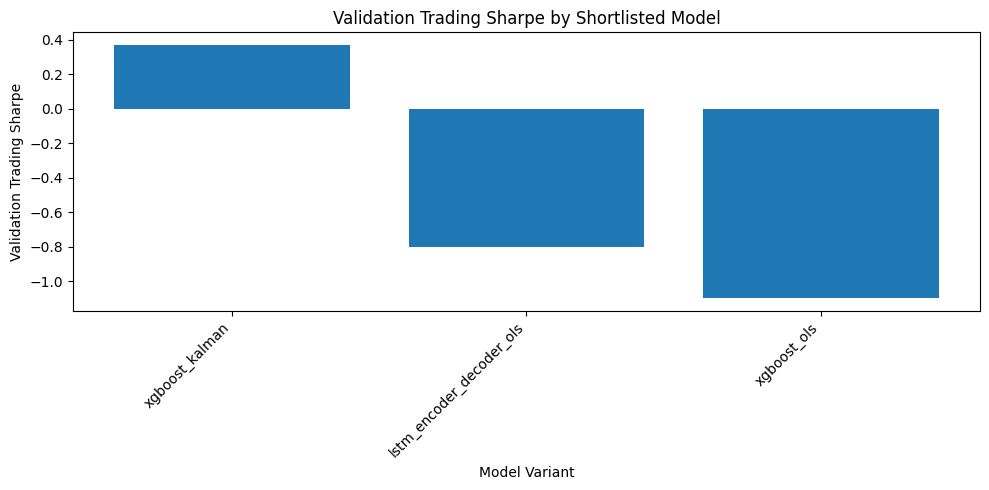

In [9]:
MODEL_SELECTION_SUMMARY = ROOT / 'outputs' / 'model_selection' / 'model_selection_summary.csv'
RUN_MODEL_SELECTION_IF_MISSING = True
MODEL_SELECTION_ARGS = ['--top_n_forecast', '3', '--skip_holdout']

if not MODEL_SELECTION_SUMMARY.exists() and RUN_MODEL_SELECTION_IF_MISSING:
    py = shutil.which('python3') or 'python3'
    cmd = [py, str(ROOT / 'scripts' / 'run_model_selection.py'), *MODEL_SELECTION_ARGS]
    print('Running trading-aware model selection:')
    print(' '.join(cmd))
    subprocess.run(cmd, check=True, cwd=ROOT)

if MODEL_SELECTION_SUMMARY.exists():
    model_selection = pd.read_csv(MODEL_SELECTION_SUMMARY)
else:
    model_selection = pd.DataFrame()

if model_selection.empty:
    print('No trading-aware model-selection summary available.')
    validation_trading_ranking = pd.DataFrame()
else:
    display_cols = [
        'model_name', 'model', 'spread_type', 'forecast_rank', 'forecast_shortlisted',
        'validation_mse_mean', 'validation_r2_mean', 'validation_information_coefficient_mean',
        'validation_directional_accuracy_mean', 'validation_profit_weighted_da_mean',
        'validation_trading_mean_sharpe', 'validation_trading_mean_fitness',
        'validation_trading_mean_return', 'validation_trading_total_trades',
        'strategy_default_mode', 'strategy_tuned', 'selected_for_live'
    ]
    display_cols = [c for c in display_cols if c in model_selection.columns]
    ranked = model_selection.sort_values(
        ['selected_for_live', 'trading_rank_within_shortlist', 'forecast_rank'],
        ascending=[False, True, True],
        na_position='last'
    )
    print('Trading-aware model-selection summary:')
    display(ranked[display_cols])

    validation_trading_ranking = model_selection[model_selection['forecast_shortlisted'].fillna(False)].copy()
    validation_trading_ranking = validation_trading_ranking.sort_values(
        ['validation_trading_mean_sharpe', 'validation_trading_mean_fitness', 'validation_trading_mean_return'],
        ascending=[False, False, False],
        na_position='last'
    ).reset_index(drop=True)
    if len(validation_trading_ranking):
        print('Validation trading ranking within forecast shortlist:')
        display(validation_trading_ranking[display_cols])

        plot_df = validation_trading_ranking.copy()
        plot_labels = plot_df['model_name']
        plt.figure(figsize=(10, 5))
        plt.bar(plot_labels, plot_df['validation_trading_mean_sharpe'])
        plt.title('Validation Trading Sharpe by Shortlisted Model')
        plt.xlabel('Model Variant')
        plt.ylabel('Validation Trading Sharpe')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('No forecast-shortlisted rows found in trading summary.')


## 7. Visualizations

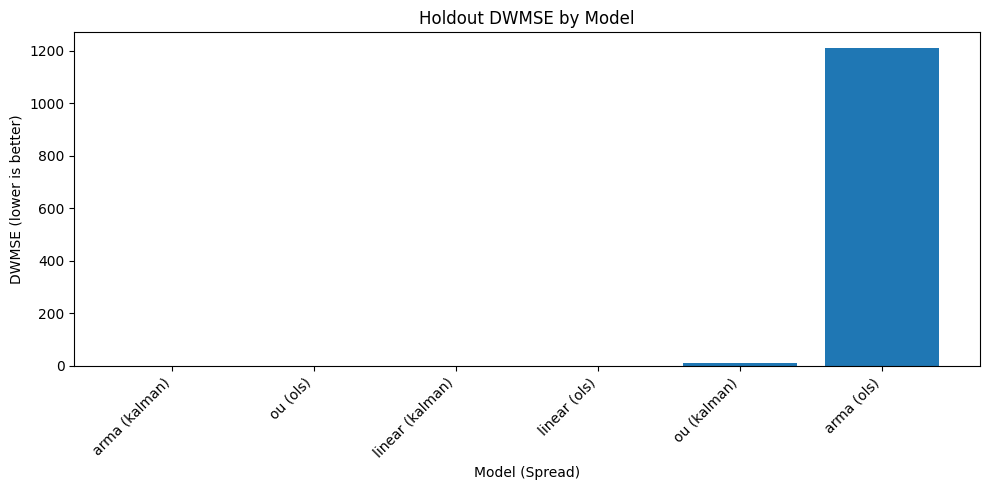

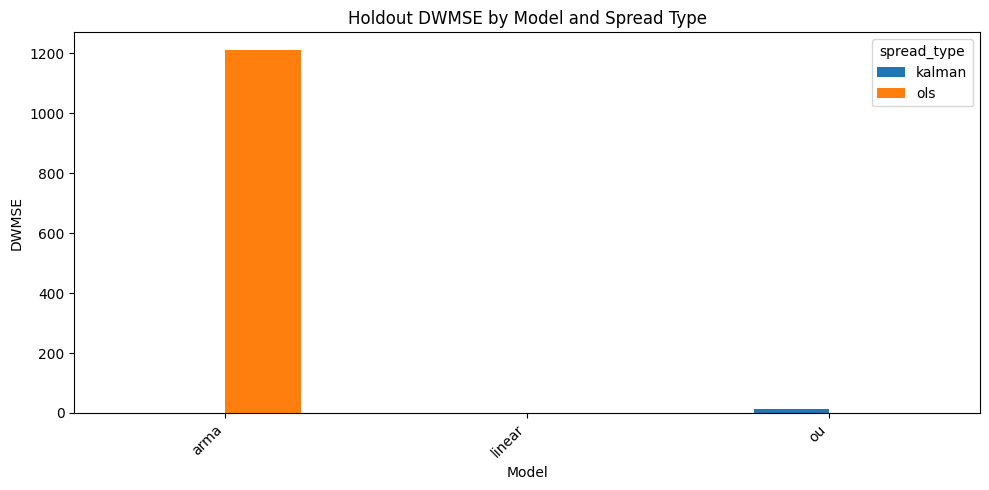

KeyError: 'avg_val_primary_metric'

In [10]:
# 1) Bar chart of holdout primary metric by model
holdout_primary = (
    holdout_rows[holdout_rows['primary_metric'].notna()]
    .groupby(['model', 'spread_type'], as_index=False)['primary_metric']
    .mean()
    .sort_values('primary_metric')
)

if len(holdout_primary):
    labels = holdout_primary['model'] + ' (' + holdout_primary['spread_type'] + ')'
    plt.figure(figsize=(10, 5))
    plt.bar(labels, holdout_primary['primary_metric'])
    plt.title('Holdout DWMSE by Model')
    plt.xlabel('Model (Spread)')
    plt.ylabel('DWMSE (lower is better)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No holdout DWMSE values available for bar chart.')

# 2) Grouped comparison by spread type
if len(holdout_primary):
    pivot_primary = holdout_primary.pivot(index='model', columns='spread_type', values='primary_metric')
    ax = pivot_primary.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Holdout DWMSE by Model and Spread Type')
    ax.set_xlabel('Model')
    ax.set_ylabel('DWMSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 3) Validation error-bar plot (mean ± std) where available
val_plot = validation_stability.copy()
val_plot = val_plot[val_plot['avg_val_primary_metric'].notna()].copy()
val_plot['std_val_primary_metric'] = val_plot['std_val_primary_metric'].fillna(0.0)
val_plot = val_plot.sort_values('avg_val_primary_metric')

if len(val_plot):
    labels = val_plot['model'] + ' (' + val_plot['spread_type'] + ')'
    plt.figure(figsize=(10, 5))
    plt.errorbar(labels, val_plot['avg_val_primary_metric'], yerr=val_plot['std_val_primary_metric'], fmt='o')
    plt.title('Validation DWMSE (mean ± std)')
    plt.xlabel('Model (Spread)')
    plt.ylabel('DWMSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No validation DWMSE values available for error-bar plot.')


In [11]:
print(df.columns.tolist())

['spread_col', 'selected_p', 'selected_q', 'mean_val_mse', 'mean_val_mae', 'n_successful_runs', 'n_windows', 'n_pairs', 'horizon', 'selection_metric']


There appears to be a very suspicious value for ARMA OLS. We will proceed to investigate this model further.

In [ ]:
arma_debug_path = ROOT / 'data' / 'processed' / 'predictions' / 'arma_ols' / '2014_2016' / 'pairs' / 'd_duk' / 'arma_forecasts_test.csv'

if not arma_debug_path.exists():
    raise FileNotFoundError(f'Missing ARMA debug file: {arma_debug_path}')

df = pd.read_csv(arma_debug_path)

# adjust column names if needed
y_true_col = "actual_value"
y_pred_col = "predicted_value"

df["abs_err"] = (df[y_true_col] - df[y_pred_col]).abs()
df["sq_err"] = (df[y_true_col] - df[y_pred_col]) ** 2

print(df[[y_true_col, y_pred_col, "abs_err", "sq_err"]]
      .sort_values("sq_err", ascending=False)
      .head(20))

print("max abs err:", df["abs_err"].max())
print("median abs err:", df["abs_err"].median())
print("mean abs err:", df["abs_err"].mean())



    actual_value  predicted_value      abs_err        sq_err
24      1.328746      2178.788486  2177.459740  4.741331e+06
80      1.341802         3.027661     1.685859  2.842122e+00
61      1.347944         2.972852     1.624908  2.640327e+00
49      1.347264        -0.256642     1.603906  2.572513e+00
85      1.352500         2.425725     1.073225  1.151813e+00
57      1.346908         2.344812     0.997904  9.958134e-01
76      1.347575         2.317800     0.970225  9.413356e-01
88      1.359951         2.301084     0.941134  8.857323e-01
79      1.342119         2.280911     0.938791  8.813290e-01
83      1.341949         2.190065     0.848116  7.193005e-01
82      1.335018         2.180942     0.845924  7.155870e-01
90      1.358429         2.193461     0.835032  6.972785e-01
54      1.352986         2.181802     0.828816  6.869354e-01
84      1.344423         2.155082     0.810660  6.571689e-01
89      1.361263         2.103834     0.742571  5.514117e-01
66      1.345627        

In [ ]:
display(df.loc[[24]])
display(df.loc[20:28, ["actual_value", "predicted_value", "abs_err", "sq_err"]])
display(df["predicted_value"].describe())
display(df.sort_values("predicted_value", ascending=False).head(10))

,forecast_origin_date,target_date,current_spread,actual_value,predicted_value,actual_change,predicted_change,rolling_vol_20d_at_origin,predicted_z,pair,spread_col,p,q,horizon,eval_split,window_label,abs_err,sq_err
24,2017-02-07,2017-02-22,1.313891,1.328746,2178.788486,0.014854,2177.474595,0.011903,182936.054875,d|duk,spread_ols,9,8,10,test,2014_2016,2177.45974,4.741331e+06


,actual_value,predicted_value,abs_err,sq_err
20,1.315343,1.306920,0.008422,7.093584e-05
21,1.309191,1.573035,0.263845,6.961396e-02
22,1.320528,1.297075,0.023454,5.500721e-04
23,1.327549,1.256832,0.070716,5.000801e-03
24,1.328746,2178.788486,2177.459740,4.741331e+06
25,1.330615,1.307875,0.022740,5.171069e-04
26,1.332830,1.279937,0.052893,2.797654e-03
27,1.331975,1.339112,0.007136,5.092859e-05
28,1.336244,1.337984,0.001740,3.029315e-06


count     206.000000
mean       11.982719
std       151.705238
min        -0.256642
25%         1.327973
50%         1.333991
75%         1.348467
max      2178.788486
Name: predicted_value, dtype: float64

,forecast_origin_date,target_date,current_spread,actual_value,predicted_value,actual_change,predicted_change,rolling_vol_20d_at_origin,predicted_z,pair,spread_col,p,q,horizon,eval_split,window_label,abs_err,sq_err
24,2017-02-07,2017-02-22,1.313891,1.328746,2178.788486,0.014854,2177.474595,0.011903,182936.054875,d|duk,spread_ols,9,8,10,test,2014_2016,2177.459740,4.741331e+06
80,2017-05-01,2017-05-15,1.340910,1.341802,3.027661,0.000892,1.686751,0.003154,534.720663,d|duk,spread_ols,9,8,10,test,2014_2016,1.685859,2.842122e+00
61,2017-04-03,2017-04-18,1.349779,1.347944,2.972852,-0.001835,1.623073,0.004324,375.406981,d|duk,spread_ols,9,8,10,test,2014_2016,1.624908,2.640327e+00
85,2017-05-08,2017-05-22,1.354360,1.352500,2.425725,-0.001860,1.071365,0.003823,280.271831,d|duk,spread_ols,9,8,10,test,2014_2016,1.073225,1.151813e+00
57,2017-03-28,2017-04-11,1.348289,1.346908,2.344812,-0.001381,0.996523,0.005056,197.103404,d|duk,spread_ols,9,8,10,test,2014_2016,0.997904,9.958134e-01
76,2017-04-25,2017-05-09,1.345627,1.347575,2.317800,0.001948,0.972173,0.003140,309.563191,d|duk,spread_ols,9,8,10,test,2014_2016,0.970225,9.413356e-01
88,2017-05-11,2017-05-25,1.341925,1.359951,2.301084,0.018026,0.959160,0.004192,228.820771,d|duk,spread_ols,9,8,10,test,2014_2016,0.941134,8.857323e-01
79,2017-04-28,2017-05-12,1.343695,1.342119,2.280911,-0.001576,0.937215,0.003160,296.621133,d|duk,spread_ols,9,8,10,test,2014_2016,0.938791,8.813290e-01
90,2017-05-15,2017-05-30,1.341802,1.358429,2.193461,0.016627,0.851659,0.004075,208.971073,d|duk,spread_ols,9,8,10,test,2014_2016,0.835032,6.972785e-01
83,2017-05-04,2017-05-18,1.341296,1.341949,2.190065,0.000654,0.848770,0.003557,238.597008,d|duk,spread_ols,9,8,10,test,2014_2016,0.848116,7.193005e-01


Through looking deeper into the ARMA OLS model predictions from the new `arma.py` outputs, we can see that one or a few predicted values can still blow up the average error disproportionately. ARMA can explode that badly because a multi-step forecast is generated recursively, so each predicted value feeds into the next step. If the fitted ARMA model is close to non-stationary or numerically unstable, even a small error at one forecast origin can get amplified very quickly over several steps.

Therefore, for better visibility, visualizations of the model comparisons without ARMA OLS will be shown below. OU Kalman is also removed because it also has quite high MSE.



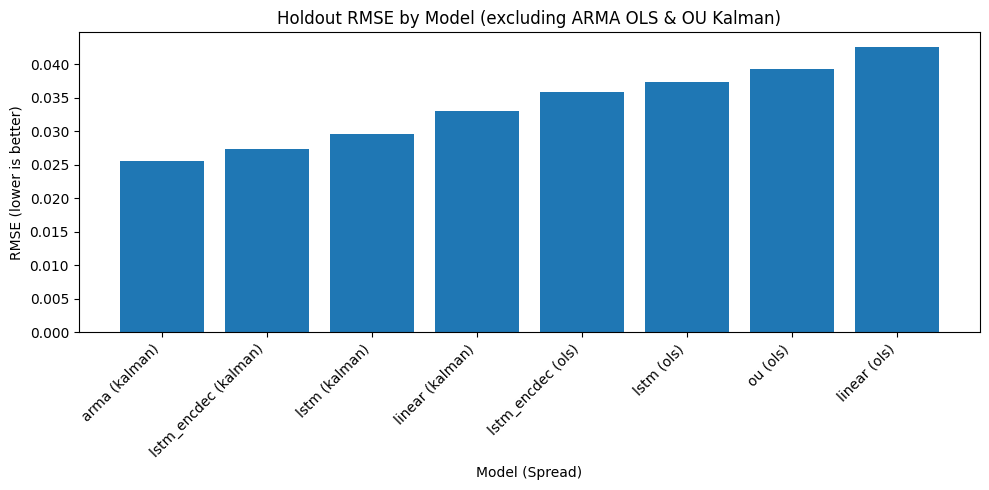

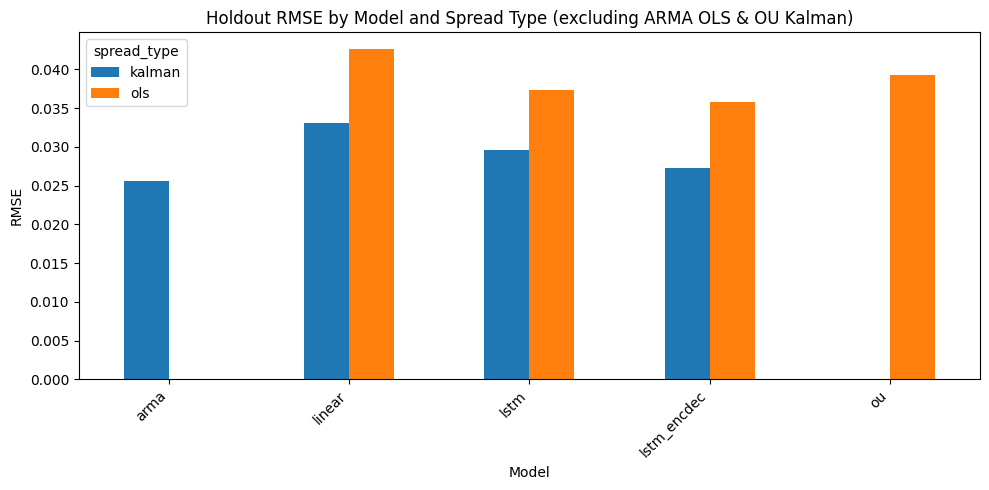

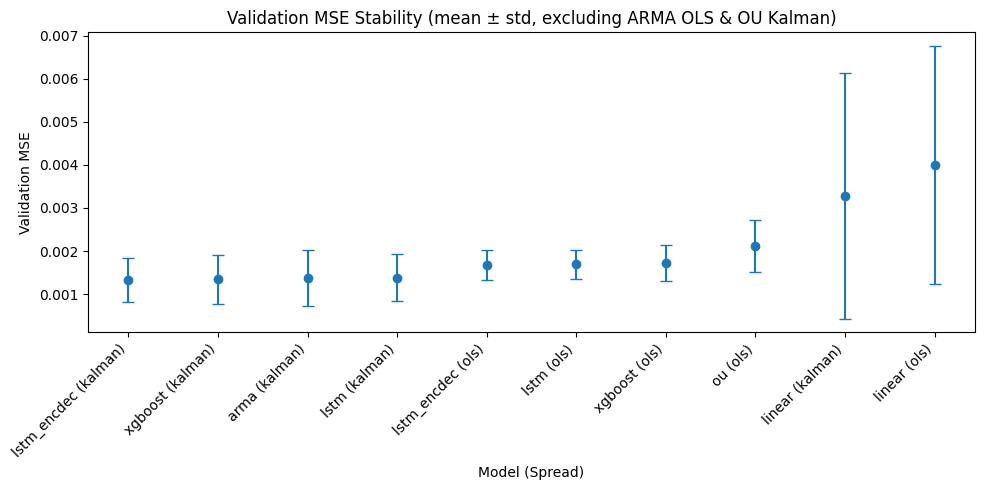

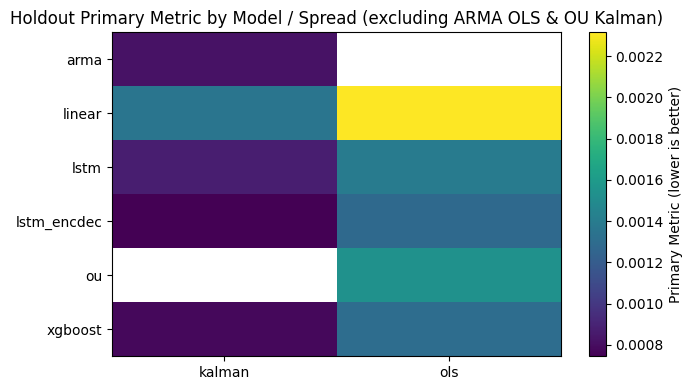

In [ ]:
# Exclude ARMA OLS & OU Kalman from plotting
holdout_rows_plot = holdout_rows[
    ~(((holdout_rows['model'] == 'arma') & (holdout_rows['spread_type'] == 'ols')) | 
      ((holdout_rows['model'] == 'ou') & (holdout_rows['spread_type'] == 'kalman')))
].copy()

holdout_ranking_plot = holdout_ranking[
    ~(((holdout_ranking['model'] == 'arma') & (holdout_ranking['spread_type'] == 'ols')) | 
      ((holdout_ranking['model'] == 'ou') & (holdout_ranking['spread_type'] == 'kalman')))
].copy()

validation_stability_plot = validation_stability[
    ~(((validation_stability['model'] == 'arma') & (validation_stability['spread_type'] == 'ols'))  | 
      ((validation_stability['model'] == 'ou') & (validation_stability['spread_type'] == 'kalman')))
].copy()

plt.style.use('default')

# 1) Bar chart of holdout DWMSE by model
holdout_primary = (
    holdout_rows_plot[holdout_rows_plot['primary_metric'].notna()]
    .groupby(['model', 'spread_type'], as_index=False)['primary_metric']
    .mean()
    .sort_values('primary_metric')
)

if len(holdout_primary):
    labels = holdout_primary['model'] + ' (' + holdout_primary['spread_type'] + ')'
    plt.figure(figsize=(10, 5))
    plt.bar(labels, holdout_primary['primary_metric'])
    plt.title('Holdout DWMSE by Model (excluding ARMA OLS & OU Kalman)')
    plt.xlabel('Model (Spread)')
    plt.ylabel('DWMSE (lower is better)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No holdout DWMSE values available for bar chart.')

# 2) Grouped comparison by spread type
if len(holdout_primary):
    pivot_primary = holdout_primary.pivot(index='model', columns='spread_type', values='primary_metric')
    ax = pivot_primary.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Holdout DWMSE by Model and Spread Type (excluding ARMA OLS & OU Kalman)')
    ax.set_xlabel('Model')
    ax.set_ylabel('DWMSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 3) Validation error-bar plot (mean ± std) where available
val_plot = validation_stability_plot.copy()
val_plot = val_plot[val_plot['avg_val_primary_metric'].notna()].copy()
val_plot['std_val_primary_metric'] = val_plot['std_val_primary_metric'].fillna(0.0)
val_plot = val_plot.sort_values('avg_val_primary_metric')

if len(val_plot):
    labels = val_plot['model'] + ' (' + val_plot['spread_type'] + ')'
    plt.figure(figsize=(10, 5))
    plt.errorbar(labels, val_plot['avg_val_primary_metric'], yerr=val_plot['std_val_primary_metric'], fmt='o')
    plt.title('Validation DWMSE (mean ± std, excluding ARMA OLS & OU Kalman)')
    plt.xlabel('Model (Spread)')
    plt.ylabel('DWMSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No validation DWMSE values available for error-bar plot.')


## 8. Interpretation

The code cell below summarizes both the forecast-screening tables and the trading-aware model-selection table.

In [ ]:
print('Holdout forecast comparison dataset:')
display(holdout_ranking)

print('Observations:')
if len(validation_ranking):
    best_v = validation_ranking.iloc[0]
    print(f"- Forecast screening still matters: the best validation forecast row by DWMSE is {best_v['model']} ({best_v['spread_type']}) with validation_primary_metric_mean={best_v['validation_primary_metric_mean']:.6g}.")
else:
    print('- No validation forecast ranking rows available.')

if 'model_selection' in globals() and len(model_selection):
    shortlisted = model_selection[model_selection['forecast_shortlisted'].fillna(False)].copy()
    selected = model_selection.loc[model_selection['selected_for_live'].fillna(False)].copy()
    print(f"- Final live selection now uses a two-stage rule: shortlist the top {len(shortlisted)} model variants by validation forecast DWMSE, then rank that shortlist by validation trading Sharpe / Fitness.")
    if len(selected):
        winner = selected.iloc[0]
        print(f"- Selected live model: {winner['model_name']} | validation trading Sharpe={winner['validation_trading_mean_sharpe']:.2f}, Fitness={winner['validation_trading_mean_fitness']:.2f}, Return={winner['validation_trading_mean_return']:.2%}.")


Holdout comparison dataset:


,model,spread_type,horizon,n_rows,holdout_mse_mean,holdout_mse_std,holdout_rank,metric_name,holdout_primary_metric,holdout_primary_metric_std,sample_metric_name
0,lstm_encdec,kalman,10.0,1,0.000745,NaN,1,mse_comparable,0.000745,NaN,mse_comparable
1,xgboost,kalman,10.0,5,0.000778,NaN,2,mse_comparable,0.000778,NaN,mse_comparable
2,arma,kalman,10.0,1,0.000821,NaN,3,mse_comparable,0.000821,NaN,mse_comparable
3,lstm,kalman,10.0,1,0.000878,NaN,4,mse_comparable,0.000878,NaN,mse_comparable
4,lstm_encdec,ols,10.0,1,0.001281,NaN,5,mse_comparable,0.001281,NaN,mse_comparable
5,xgboost,ols,10.0,5,0.001308,NaN,6,mse_comparable,0.001308,NaN,mse_comparable
6,linear,kalman,10.0,1,0.001355,NaN,7,mse_comparable,0.001355,NaN,mse_comparable
7,lstm,ols,10.0,1,0.001395,NaN,8,mse_comparable,0.001395,NaN,mse_comparable
8,ou,ols,10.0,1,0.001541,NaN,9,mse_comparable,0.001541,NaN,mse_comparable
9,linear,ols,10.0,1,0.002316,NaN,10,mse_comparable,0.002316,NaN,mse_comparable


Observations:
- Clean error comparison now uses one aggregate row per model × spread × split; top holdout entry by MSE is lstm_encdec (kalman) with holdout_mse_mean=0.000744507.
- Validation ranking is also aggregated at the same grain; best validation entry is lstm_encdec (kalman) with validation_mse_mean=0.00132381.
- OU is now included by deriving forecast-error metrics from ou_signals_* and comparing pred_spread_10d with realized t+10 spread.
- Tuning summaries are shown separately and are not part of final ranking tables.
- Final model selection should prioritize cleaned holdout MSE, then be confirmed with backtest results.


Forecast accuracy and trading performance should now be interpreted as different layers of evidence. Low validation or holdout MSE can still help narrow the candidate set, but it is no longer treated as if it directly implied tradable edge. The trading-aware summary makes this explicit by placing R², IC, directional accuracy, and profit-weighted directional accuracy next to validation trading Sharpe, Fitness, and realized return.

This means the notebook can distinguish between a model that predicts well in a statistical sense and a model whose predictions survive costs, turnover, and portfolio construction. That distinction is critical in this project because several model variants show respectable forecast metrics while still producing weak trading results once the actual strategy logic is applied.

## 9. Final Conclusion

The final live-model decision should now follow a causal two-stage rule: use validation forecast metrics to shortlist candidates, then select the live model from the shortlisted set by **validation trading Sharpe / Fitness**. This keeps the notebook aligned with the actual objective of the project, which is tradable performance rather than low error alone.

Under this rule, forecast metrics remain important because they help identify whether a model has real informational content, but they are no longer the end of the decision process. The preferred spread representation and model family should therefore be the ones that stay strong after the validation backtest layer is applied, with holdout used only as an ex-post check on whether that trading edge generalized.